In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.graphics.correlation as sgc
from statsmodels.graphics.gofplots import qqplot
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import OLSInfluence
import seaborn as sns

In [2]:
# Read the database, and clean the data using the processing modules we built.

import re
import numpy as np
import pandas as pd
from field_data_processor import FieldDataProcessor
# from weather_data_processor import WeatherDataProcessor
import logging 

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')

config_params = {
    "sql_query": """
            SELECT *
            FROM geographic_features
            LEFT JOIN weather_features USING (Field_ID)
            LEFT JOIN soil_and_crop_features USING (Field_ID)
            LEFT JOIN farm_management_features USING (Field_ID)
            """,
    "db_path": 'sqlite:///Maji_Ndogo_farm_survey_small.db',
    "columns_to_rename": {'Annual_yield': 'Crop_type', 'Crop_type': 'Annual_yield'},
    "values_to_rename": {'teaa':'tea',
                                            'cassaval':'cassava',
                                            'cassava ':'cassava',
                                            'tea ': 'tea',
                                            'wheat ': 'wheat',
                                            'wheatn': 'wheat'},
    "weather_csv_path": "https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Maji_Ndogo/Weather_station_data.csv",
    "weather_mapping_csv": "https://raw.githubusercontent.com/Explore-AI/Public-Data/master/Maji_Ndogo/Weather_data_field_mapping.csv",
    "regex_patterns" : {
            'Rainfall': r'(\d+(\.\d+)?)\s?mm',
            'Temperature': r'(\d+(\.\d+)?)\s?C',
            'Pollution_level': r'=\s*(-?\d+(\.\d+)?)|Pollution at \s*(-?\d+(\.\d+)?)'
            },
}
# Ignoring the field data for now.
field_processor = FieldDataProcessor(config_params)
field_processor.process()
field_df = field_processor.df

# We're not going to use the weather data this time, so we'll ignore it.
# weather_processor = WeatherDataProcessor(config_params)
# weather_processor.process()
# weather_df = weather_processor.weather_df

dataset = field_df.drop("Weather_station", axis=1)

2026-01-30 16:14:59,348 - data_ingestion - INFO - Database engine created successfully.
2026-01-30 16:14:59,515 - data_ingestion - INFO - Query executed successfully.
2026-01-30 16:14:59,518 - field_data_processor.FieldDataProcessor - INFO - Sucessfully loaded data.
2026-01-30 16:14:59,522 - field_data_processor.FieldDataProcessor - INFO - Swapped columns: Annual_yield with Crop_type
2026-01-30 16:15:01,431 - data_ingestion - INFO - CSV file read successfully from the web.


In [3]:
# Validate the data
#!pip install pytest

dataset.to_csv('sampled_field_df.csv', index=False)

!pytest validate_data.py -v

import os# Define the file paths
field_csv_path = 'sampled_field_df.csv'

# Delete sampled_field_df.csv if it exists
if os.path.exists(field_csv_path):
    os.remove(field_csv_path)
    print(f"Deleted {field_csv_path}")
else:
    print(f"{field_csv_path} does not exist.")

============================= test session starts =============================
platform win32 -- Python 3.13.5, pytest-8.3.4, pluggy-1.5.0 -- C:\ProgramData\anaconda3\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\didie\Downloads
plugins: anyio-4.7.0
collecting ... collected 0 items

============================ no tests ran in 0.31s ============================
Deleted sampled_field_df.csv


In [4]:
dataset = dataset.applymap(lambda x: x.strip() if isinstance(x, str) else x)

C:\Users\didie\AppData\Local\Temp\ipykernel_5232\364646439.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  dataset = dataset.applymap(lambda x: x.strip() if isinstance(x, str) else x)


In [5]:
type(dataset)

pandas.core.frame.DataFrame

In [6]:
dataset.shape

(5654, 18)

In [7]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5654 entries, 0 to 5653
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Field_ID           5654 non-null   int64  
 1   Elevation          5654 non-null   float64
 2   Latitude           5654 non-null   float64
 3   Longitude          5654 non-null   float64
 4   Location           5654 non-null   object 
 5   Slope              5654 non-null   float64
 6   Rainfall           5654 non-null   float64
 7   Min_temperature_C  5654 non-null   float64
 8   Max_temperature_C  5654 non-null   float64
 9   Ave_temps          5654 non-null   float64
 10  Soil_fertility     5654 non-null   float64
 11  Soil_type          5654 non-null   object 
 12  pH                 5654 non-null   float64
 13  Pollution_level    5654 non-null   float64
 14  Plot_size          5654 non-null   float64
 15  Annual_yield       5654 non-null   float64
 16  Crop_type          5654 

In [8]:
dataset=dataset.drop('Field_ID',axis=1)

# Q1. The dataset has 16 predictors and Location, soil type and crop type as categorical variable

In [9]:
dataset['Crop_type'].unique()

array(['cassava', 'tea', 'wheat', 'potato', 'banana', 'coffee', 'rice',
       'maize'], dtype=object)

In [10]:
dataset_encoded = pd.get_dummies(dataset, columns=['Location','Soil_type','Crop_type'], drop_first=True)
dataset_encoded = dataset_encoded.astype(int)
dataset_encoded1 = dataset_encoded.copy()
dataset_encoded1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5654 entries, 0 to 5653
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   Elevation                5654 non-null   int64
 1   Latitude                 5654 non-null   int64
 2   Longitude                5654 non-null   int64
 3   Slope                    5654 non-null   int64
 4   Rainfall                 5654 non-null   int64
 5   Min_temperature_C        5654 non-null   int64
 6   Max_temperature_C        5654 non-null   int64
 7   Ave_temps                5654 non-null   int64
 8   Soil_fertility           5654 non-null   int64
 9   pH                       5654 non-null   int64
 10  Pollution_level          5654 non-null   int64
 11  Plot_size                5654 non-null   int64
 12  Annual_yield             5654 non-null   int64
 13  Standard_yield           5654 non-null   int64
 14  Location_Rural_Amanzi    5654 non-null   int64
 15  Loca

# Q2. After encoding categorical variables the whole  independent  variables are 29 excluding dependent  variable.

In [11]:
categorical_cols = ['Location', 'Soil_type', 'Crop_type']  # example
dataset_encoded = pd.get_dummies(dataset, columns=categorical_cols)
dummy_cols = [col for col in dataset_encoded.columns if 
              col.startswith('Location_') or 
              col.startswith('Soil_type_') or 
              col.startswith('Crop_type_')]

# Convert only those to int
dataset_encoded[dummy_cols] = dataset_encoded[dummy_cols].astype(int)


In [12]:
# Step 1: Compute correlation matrix
corr = dataset_encoded.corr()

# Step 2: Extract correlations with Standard_yield (excluding itself)
corr_standard = corr['Standard_yield'].drop('Standard_yield')

# Step 3: Sort by absolute correlation strength
sorted_corr = corr_standard.abs().sort_values(ascending=False)

# Step 4: Get the third highest
third_var = sorted_corr.index[2]   # 0 = highest, 1 = second, 2 = third
third_val = corr_standard[third_var]  # actual signed correlation

print("Third highest absolute correlation:", third_var)
print("Correlation value:", third_val)

Third highest absolute correlation: Pollution_level
Correlation value: -0.2857609646210543


# Q3. The Highest ABS is Population_level

# Q4. The boolean columns have been replaced with binary integer representations, with True converted to 1 and False converted to 0.

In [13]:
dataset_encode=dataset_encoded.copy()
dataset_encode.columns
filtered=dataset_encode
col_to_move = "Standard_yield"
cols = list(filtered.columns)
cols.remove(col_to_move)
cols.insert(0, col_to_move)
dataset_encoded = dataset_encoded[cols]

In [14]:
formula_str = "Standard_yield ~ " + " + ".join(dataset_encoded.columns.drop("Standard_yield"))
formula_str

'Standard_yield ~ Elevation + Latitude + Longitude + Slope + Rainfall + Min_temperature_C + Max_temperature_C + Ave_temps + Soil_fertility + pH + Pollution_level + Plot_size + Annual_yield + Location_Rural_Akatsi + Location_Rural_Amanzi + Location_Rural_Hawassa + Location_Rural_Kilimani + Location_Rural_Sokoto + Soil_type_Loamy + Soil_type_Peaty + Soil_type_Rocky + Soil_type_Sandy + Soil_type_Silt + Soil_type_Volcanic + Crop_type_banana + Crop_type_cassava + Crop_type_coffee + Crop_type_maize + Crop_type_potato + Crop_type_rice + Crop_type_tea + Crop_type_wheat'

In [15]:
formula = "Standard_yield ~ " + " + ".join(dataset_encoded.columns.drop("Standard_yield"))
model = smf.ols(formula=formula, data=dataset_encoded).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         Standard_yield   R-squared:                       0.756
Model:                            OLS   Adj. R-squared:                  0.755
Method:                 Least Squares   F-statistic:                     623.8
Date:                Fri, 30 Jan 2026   Prob (F-statistic):               0.00
Time:                        16:15:05   Log-Likelihood:                 8358.2
No. Observations:                5654   AIC:                        -1.666e+04
Df Residuals:                    5625   BIC:                        -1.647e+04
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

In [16]:
# Get p-values from your model
p_values = model.pvalues

# Identify variables with p-values > 0.05 (not statistically significant)
insignificant = p_values[p_values > 0.05]

print(insignificant)

Elevation            0.530099
Slope                0.076909
Rainfall             0.056670
Min_temperature_C    0.203241
Max_temperature_C    0.184350
Ave_temps            0.211375
Soil_fertility       0.166702
Soil_type_Silt       0.108084
Crop_type_banana     0.890028
Crop_type_coffee     0.959456
dtype: float64


# Q5. PH is the variable which is statistically siginnificant among the option.

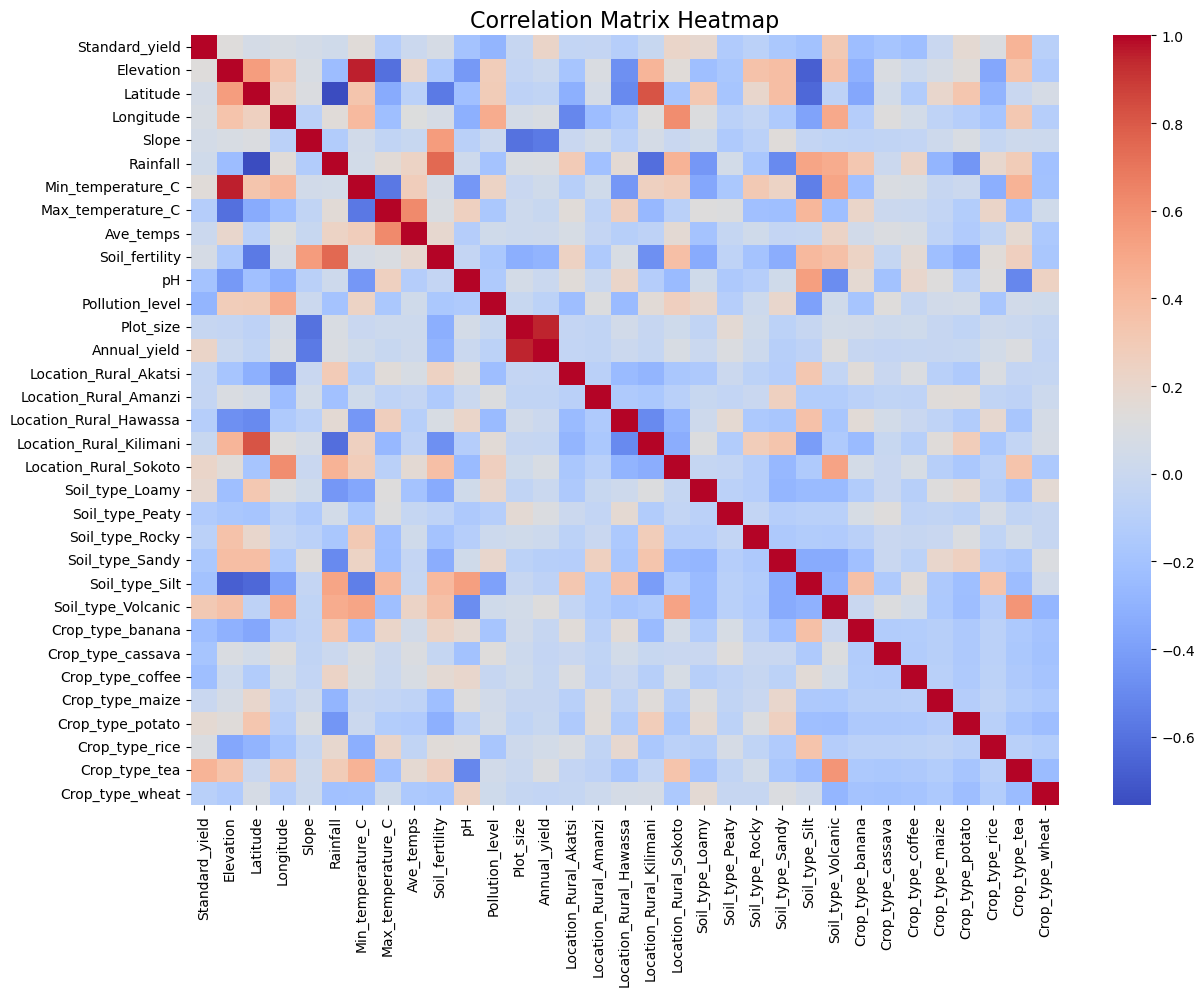

In [17]:
corr_matrix = dataset_encoded.corr()

# Step 2: Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False, cbar=True)
plt.title("Correlation Matrix Heatmap", fontsize=16)
plt.show()


# Q6 The  independent variables have a strong correlation with one another
    Min_temperature_C and Elevation


In [18]:
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         Standard_yield   R-squared:                       0.756
Model:                            OLS   Adj. R-squared:                  0.755
Method:                 Least Squares   F-statistic:                     623.8
Date:                Fri, 30 Jan 2026   Prob (F-statistic):               0.00
Time:                        16:15:06   Log-Likelihood:                 8358.2
No. Observations:                5654   AIC:                        -1.666e+04
Df Residuals:                    5625   BIC:                        -1.647e+04
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                 

# Q7. The F-statistic tests the overall significance of the regression model. A high F-statistic value with a corresponding low p-value indicates that the regression model is statistically significant, meaning that at least one of the independent variables has a significant effect on the dependent variable.

In [19]:
df1=dataset_encoded[['Standard_yield','Pollution_level','Crop_type_coffee','Crop_type_tea','Location_Rural_Sokoto','Annual_yield','Soil_type_Silt','Soil_type_Volcanic']]

In [20]:
formula = "Standard_yield ~ " + " + ".join(df1.columns.drop("Standard_yield"))
model = smf.ols(formula=formula, data=dataset_encoded).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:         Standard_yield   R-squared:                       0.406
Model:                            OLS   Adj. R-squared:                  0.406
Method:                 Least Squares   F-statistic:                     552.1
Date:                Fri, 30 Jan 2026   Prob (F-statistic):               0.00
Time:                        16:15:07   Log-Likelihood:                 5839.8
No. Observations:                5654   AIC:                        -1.166e+04
Df Residuals:                    5646   BIC:                        -1.161e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                 0.56

# Q8. The model worsened

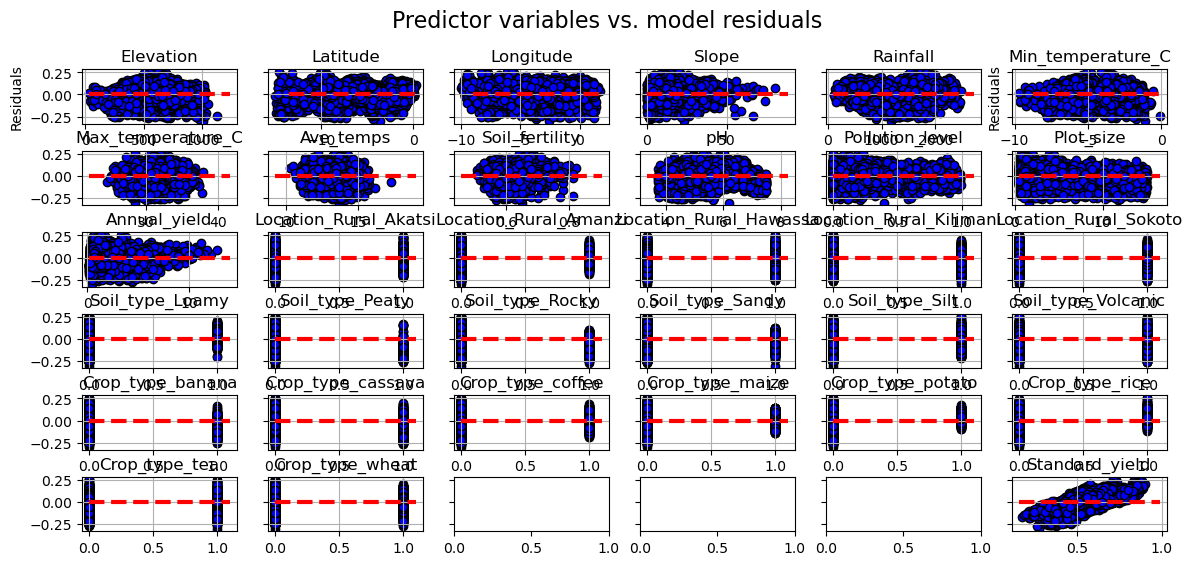

In [21]:
fig, axs = plt.subplots(6,6, figsize=(14,6),sharey=True)
fig.subplots_adjust(hspace = 0.5, wspace=.2)
fig.suptitle('Predictor variables vs. model residuals', fontsize=16)
axs = axs.ravel()

for index, column in enumerate(dataset_encoded.columns):
    axs[index-1].set_title("{}".format(column),fontsize=12)
    axs[index-1].scatter(x=dataset_encoded[column],y=model.resid,color='blue',edgecolor='k')
    axs[index-1].grid(True)
    xmin = min(dataset_encoded[column])
    xmax = max(dataset_encoded[column])
    axs[index-1].hlines(y=0,xmin=xmin*0.9,xmax=xmax*1.1,color='red',linestyle='--',lw=3)
    if index == 1 or index == 6:
        axs[index-1].set_ylabel('Residuals')

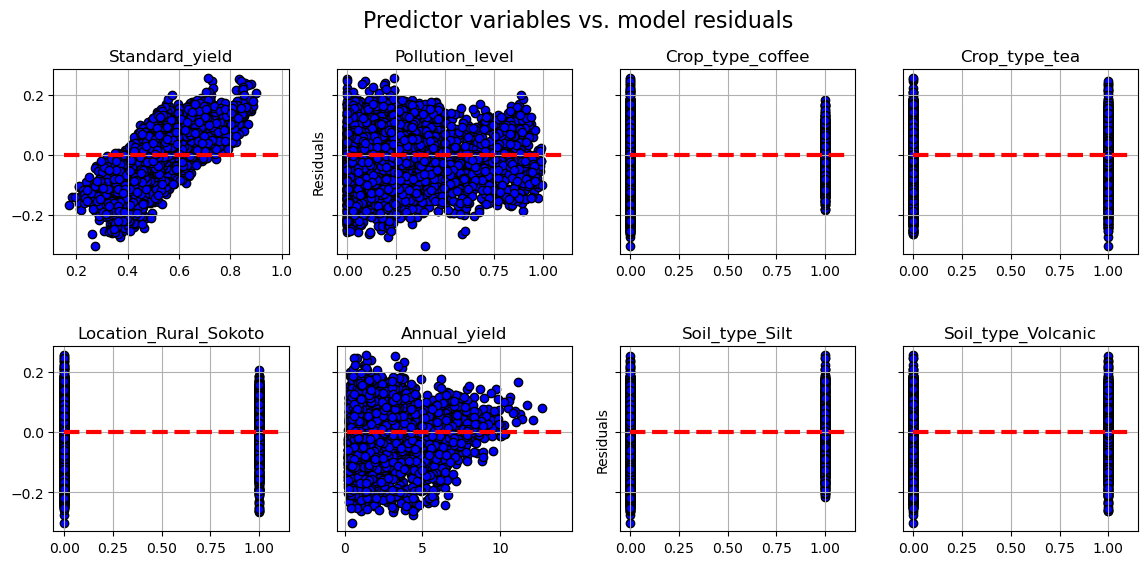

In [22]:
import matplotlib.pyplot as plt

# Number of predictors
n = len(df1.columns)

# Create subplots grid dynamically
rows = 2
cols = (n + 1) // 2   # ensures enough columns

fig, axs = plt.subplots(rows, cols, figsize=(14,6), sharey=True)
fig.subplots_adjust(hspace=0.5, wspace=0.2)
fig.suptitle('Predictor variables vs. model residuals', fontsize=16)

axs = axs.ravel()

for index, column in enumerate(df1.columns):
    axs[index].set_title(column, fontsize=12)
    axs[index].scatter(x=df1[column], y=model.resid, color='blue', edgecolor='k')
    axs[index].grid(True)
    xmin, xmax = df1[column].min(), df1[column].max()
    axs[index].hlines(y=0, xmin=xmin*0.9, xmax=xmax*1.1, color='red', linestyle='--', lw=3)
    if index == 1 or index == 6:
        axs[index].set_ylabel('Residuals')

# Q9. The plot indicates homoscedasticity as residuals have a constant variance and are distributed randomly around the zero residual line.

# Q10. All of the above.

In [23]:

from sklearn.preprocessing import StandardScaler

# Insert selected option here

dataset['Temperature_Range'] = dataset['Max_temperature_C'] - dataset['Min_temperature_C']

# Select features for scaling (exclude non-numeric or target variables)
features = ['Elevation', 'Slope', 'Rainfall', 'Ave_temps', 'Temperature_Range', 'Soil_fertility', 'pH', 'Pollution_level']

# Initialise StandardScaler and apply it to the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(dataset[features])

# Show the first 5 rows of the scaled features
print(scaled_features[:5])

[[ 0.85426539  0.31997088 -0.15356676  2.21747303  0.30626766  0.01544079
   0.71256827 -0.61634976]
 [ 0.21055364 -0.03858151  0.49777372  0.15900087 -0.25298298  0.4619994
   0.08816394  0.7886906 ]
 [ 1.08748981 -0.04224188  2.01496684  0.09662293 -1.66755812  1.57839593
  -0.34858051  0.60254524]
 [-0.3620941  -0.4856324  -1.74719984 -0.02813296  0.8984154  -1.77079366
  -0.35345077  0.28374058]
 [ 1.43215211  4.53523034 -0.83392242  1.28180387 -0.58195394  2.24823384
   0.14466333 -0.80437805]]


In [24]:
dataset.head()

,Elevation,Latitude,Longitude,Location,Slope,Rainfall,Min_temperature_C,Max_temperature_C,Ave_temps,Soil_fertility,Soil_type,pH,Pollution_level,Plot_size,Annual_yield,Crop_type,Standard_yield,Temperature_Range
0,786.05580,-7.389911,-7.556202,Rural_Akatsi,14.795113,1125.2,-3.1,33.1,15.00,0.62,Sandy,6.169393,0.085267,1.3,0.751354,cassava,0.577964,36.2
1,674.33410,-7.736849,-1.051539,Rural_Sokoto,11.374611,1450.7,-3.9,30.6,13.35,0.64,Volcanic,5.676648,0.399684,2.2,1.069865,cassava,0.486302,34.5
2,826.53390,-9.926616,0.115156,Rural_Sokoto,11.339692,2208.9,-1.8,28.4,13.30,0.69,Volcanic,5.331993,0.358029,3.4,2.208801,tea,0.649647,30.2
3,574.94617,-2.420131,-6.592215,Rural_Kilimani,7.109855,328.8,-5.8,32.2,13.20,0.54,Loamy,5.328150,0.286687,2.4,1.277635,cassava,0.532348,38.0
4,886.35300,-3.055434,-7.952609,Rural_Kilimani,55.007656,785.2,-2.5,31.0,14.25,0.72,Sandy,5.721234,0.043190,1.5,0.832614,wheat,0.555076,33.5


# Q11. dataset['Temperature_Range'] = dataset['Max_temperature_C'] - dataset['Min_temperature_C']

In [25]:
from sklearn.linear_model import LassoCV

# scaled_features is our matrix of scaled features and dataset['Standard_yield'] is the target variable
lasso = LassoCV(cv=5).fit(scaled_features, dataset['Standard_yield'])

# Find the features with non-zero coefficients
selected_features = [features[i] for i, coef in enumerate(lasso.coef_) if coef != 0]

# Q12. It indicates that 5-fold cross-validation should be used to select the best regularisation parameter.

In [26]:
from sklearn.linear_model import RidgeCV

# Insert selected option here

alphas=[0.001, 0.01, 0.1, 1, 10, 100]
# Apply Ridge regression with cross-validation
ridge = RidgeCV(alphas=alphas, cv=5).fit(scaled_features, dataset['Standard_yield'])

# Q13. alphas=[0.001, 0.01, 0.1, 1, 10, 100]

In [27]:
from sklearn.preprocessing import PolynomialFeatures

# Generate polynomial and interaction features
#Insert selected option here
poly = PolynomialFeatures(degree=2, include_bias= False)
poly_features = poly.fit_transform(dataset[['Elevation', 'Slope']])

# Display the shape of the new feature matrix
poly_features.shape

(5654, 5)

# Q14. poly = PolynomialFeatures(degree=2, include_bias= False)

In [28]:
from sklearn.linear_model import Ridge
import numpy as np

# Assuming `X` is the feature matrix and `y` is the target variable
X = np.array([[0.5, 0.2, 0.1],
              [0.9, 0.3, 0.5],
              [0.3, 0.8, 0.2]])
y = np.array([0.7, 0.6, 0.8])

# Fit Ridge regression model with alpha = 0.1
ridge_model = Ridge(alpha=0.1)
ridge_model.fit(X, y)

# Display the coefficients of the model
ridge_model.coef_

array([-0.13661379,  0.10262221, -0.07348657])

# Q15. Feature 2 has the highest positive impact, while Feature 3 and Feature 1 have negative impacts.

In [29]:
dataset_encoded.head()

,Standard_yield,Elevation,Latitude,Longitude,Slope,Rainfall,Min_temperature_C,Max_temperature_C,Ave_temps,Soil_fertility,...,Soil_type_Silt,Soil_type_Volcanic,Crop_type_banana,Crop_type_cassava,Crop_type_coffee,Crop_type_maize,Crop_type_potato,Crop_type_rice,Crop_type_tea,Crop_type_wheat
0,0.577964,786.05580,-7.389911,-7.556202,14.795113,1125.2,-3.1,33.1,15.00,0.62,...,0,0,0,1,0,0,0,0,0,0
1,0.486302,674.33410,-7.736849,-1.051539,11.374611,1450.7,-3.9,30.6,13.35,0.64,...,0,1,0,1,0,0,0,0,0,0
2,0.649647,826.53390,-9.926616,0.115156,11.339692,2208.9,-1.8,28.4,13.30,0.69,...,0,1,0,0,0,0,0,0,1,0
3,0.532348,574.94617,-2.420131,-6.592215,7.109855,328.8,-5.8,32.2,13.20,0.54,...,0,0,0,1,0,0,0,0,0,0
4,0.555076,886.35300,-3.055434,-7.952609,55.007656,785.2,-2.5,31.0,14.25,0.72,...,0,0,0,0,0,0,0,0,0,1


In [30]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
import numpy as np

X= dataset_encoded1.drop('Standard_yield', axis=1)
Y= dataset_encoded['Standard_yield']
X_train, X_test, Y_train, Y_test= train_test_split(X, Y, test_size=0.2, random_state=42)

dt=DecisionTreeRegressor(max_depth=2, random_state=42)
dt.fit(X_train, Y_train)

y_pred = dt.predict(X_test)


# Predict on the given x-values
# Get the feature names from your training set
feature_names = X_train.columns   # or X.columns if you prefer

# Now build the DataFrame with the same column names
x_values_df = pd.DataFrame([[
    864.66138, -8.12890218821531, -8.311822719284072, 16.274624300000003,
    1237.7200000000003, -3.4100000000000006, 36.410000000000004, 16.5,
    0.682, 6.7863323423108195, 0.09379352739936421, 1.4300000000000002,
    0.8264890400277934, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.1, 0.0, 0.0,
    1.1, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
]], columns=feature_names)

# Predict safely
y_new_pred = dt.predict(x_values_df)
print("Prediction for given x_values:", round(y_new_pred[0], 4))


Prediction for given x_values: 0.485


In [31]:
dataset_encoded1.columns

Index(['Elevation', 'Latitude', 'Longitude', 'Slope', 'Rainfall',
       'Min_temperature_C', 'Max_temperature_C', 'Ave_temps', 'Soil_fertility',
       'pH', 'Pollution_level', 'Plot_size', 'Annual_yield', 'Standard_yield',
       'Location_Rural_Amanzi', 'Location_Rural_Hawassa',
       'Location_Rural_Kilimani', 'Location_Rural_Sokoto', 'Soil_type_Peaty',
       'Soil_type_Rocky', 'Soil_type_Sandy', 'Soil_type_Silt',
       'Soil_type_Volcanic', 'Crop_type_cassava', 'Crop_type_coffee',
       'Crop_type_maize', 'Crop_type_potato', 'Crop_type_rice',
       'Crop_type_tea', 'Crop_type_wheat'],
      dtype='object')

# Q16.  0.485

In [32]:
from sklearn.metrics import mean_squared_error
mse= mean_squared_error(y_pred, Y_test)
rmse=np.sqrt(mse)
print(round(rmse,7))

0.0874975


# Q17.  0.08749745433509085 which is approximately to 0.0881

# Q18. An RMSE of 0.0881 suggests that, on average, the predicted values are off by approximately 0.0881 units.

# Q19. Higher max_depth values may lead to increased model complexity and a higher risk of overfitting.

# Q20. False

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.utils import resample
import numpy as np

# X_train, y_train represent the features and target variable from the training data
X = dataset[['Elevation', 'Slope', 'Soil_fertility', 'Pollution_level']]
y = dataset['Standard_yield']

predictions = []
n_bootstrap_samples = 100

for _ in range(n_bootstrap_samples):
    X_sample, y_sample = resample(X, y)
    model = LinearRegression()
    model.fit(X_sample, y_sample)
    y_pred = model.predict(X)
    predictions.append(y_pred)

# MISSING PART HERE
bagged_predictions = np.mean(predictions, axis=0)

mse_bagged = mean_squared_error(y, bagged_predictions)


print(f"Mean Squared Error of Bagged Linear Regression Models: {mse_bagged}")


Mean Squared Error of Bagged Linear Regression Models: 0.010840480934104413


# Q21. 

    bagged_prediction = np.mean(predictions, axis=0)

    mse_bagged = mean_squared_error(y, bagged_prediction)


# Q22. max_features.

In [34]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
from sklearn.ensemble import StackingRegressor
from sklearn.metrics import mean_squared_error

# Define base learners
estimators = [
    ('lr', LinearRegression()),
    ('ridge', Ridge()),
    ('svr', SVR(kernel='linear'))
]

# Define the theoretical stacking model
stacking_model = StackingRegressor(estimators=estimators, final_estimator=LinearRegression())

# Note: Assume X, y represent the features and target variable respectively, for a theoretical prediction scenario.

# Q23. linear

In [35]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score
import numpy as np

# Initialise the ridge regression model
ridge_model = Ridge()

# Perform 5-fold cross-validation with bootstrapping
scores = cross_val_score(ridge_model, X, y, scoring='neg_mean_squared_error', cv=5) #add correct option here 

# Convert scores to positive MSE
mse_scores = -scores

# Calculate average MSE
average_mse = np.mean(mse_scores)
print(f"Average Mean Squared Error from Cross-Validation: {average_mse}")

Average Mean Squared Error from Cross-Validation: 0.010875483717316465


# Q24. scoring='neg_mean_squared_error', cv=5

# Q25. The code identifies and prints the importance scores for each feature in the random forest model, indicating how much each feature contributes to the model's ability to predict Standard_yield. Higher scores suggest a greater contribution to the prediction.

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

def train_rf_model(rf_model, dataset, target_column='Standard_yield'):
    
    # Separate features (X) and target (y)
    X = dataset.drop(columns=[target_column])
    y = dataset[target_column]
    
    # Split into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    
    # Fit the model
    rf_model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = rf_model.predict(X_test)
    
    # Evaluate performance
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    
    return rf_model, r2, mse

In [37]:
rf = RandomForestRegressor(max_depth=15, random_state=42)

trained_model, r2, mse = train_rf_model(rf, dataset_encoded)

print("R-squared:", round(r2,5))
print("Mean Squared Error:", round(mse,5))


R-squared: 0.95875
Mean Squared Error: 0.00055


# Q26. R2: 0.9586, MSE: 0.0006

In [38]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Separate features and target
X = dataset_encoded1.drop(columns=['Standard_yield'])
y = dataset_encoded['Standard_yield']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Model with 150 trees
rf_150 = RandomForestRegressor(n_estimators=150, random_state=42)
rf_150.fit(X_train, y_train)
y_pred_150 = rf_150.predict(X_test)
mse_150 = mean_squared_error(y_test, y_pred_150)

# Model with 200 trees
rf_200 = RandomForestRegressor(n_estimators=200, random_state=42)
rf_200.fit(X_train, y_train)
y_pred_200 = rf_200.predict(X_test)
mse_200 = mean_squared_error(y_test, y_pred_200)

print("MSE with 150 trees:", mse_150)
print("MSE with 200 trees:", mse_200)

MSE with 150 trees: 0.000987674381753307
MSE with 200 trees: 0.0009868795765274586


# Q27. The model with 200 trees showed a very slight decrease in error compared to the model with 150 trees.

# Q28. Increasing the number of trees increases the model’s predictive ability up to a certain point, after which additional trees do not significantly impact performance.

Top 3 features:
          Feature  Importance
4        Rainfall    0.194741
30  Crop_type_tea    0.182603
1        Latitude    0.153893


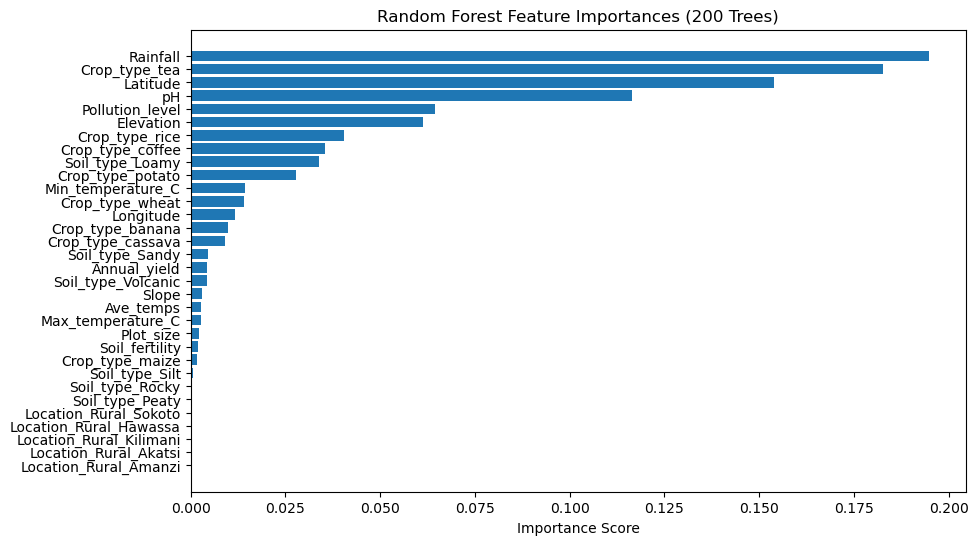

In [42]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

# Separate features and target
X = dataset_encoded.drop('Standard_yield', axis=1)
y = dataset_encoded['Standard_yield']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Random Forest with 200 trees
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

# Extract feature importances
importances = rf.feature_importances_
feature_names = X.columns

# Create a DataFrame for easy viewing
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print("Top 3 features:")
print(importance_df.head(3))

# Plot feature importances
plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'], importance_df['Importance'])
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.title("Random Forest Feature Importances (200 Trees)")
plt.show()

In [41]:
type(dataset)

pandas.core.frame.DataFrame

# Q29. Rainfall, Crop_type_tea, Latitude

# Q30. RandomForestRegressor(n_estimators=150, max_depth=None, oob_score=True)

# Q31. Defining roles and responsibilities clearly 

# Q32. False

# Q33. To provide standards for behaviour and practices 

# Q34. False

# Q35. False